In [2]:
# !pip install astropy
# !pip install scikit-image

import os

from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import SkyCoord
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from matplotlib.patches import Ellipse

import re
from astropy.wcs import WCS

from skimage.draw import ellipse

In [3]:
isCatalogueOriginal = True

In [4]:
fits_path = "../data/raw/fits/jw02107-o039_t018_miri_f770w_i2d.fits"

hdul = fits.open(fits_path)
hdul.info()

Filename: ../data/raw/fits/jw02107-o039_t018_miri_f770w_i2d.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     265   ()      
  1  SCI           1 ImageHDU        75   (2380, 1177)   float32   
  2  ERR           1 ImageHDU        10   (2380, 1177)   float32   
  3  CON           1 ImageHDU        10   (2380, 1177, 1)   int32   
  4  WHT           1 ImageHDU         9   (2380, 1177)   float32   
  5  VAR_POISSON    1 ImageHDU         9   (2380, 1177)   float32   
  6  VAR_RNOISE    1 ImageHDU         9   (2380, 1177)   float32   
  7  VAR_FLAT      1 ImageHDU         9   (2380, 1177)   float32   
  8  HDRTAB        1 BinTableHDU    502   12R x 246C   [23A, 5A, 3A, 48A, 7A, 13A, 6A, 5A, 6A, 7A, 10A, 4A, L, D, D, 32A, 50A, 70A, 11A, 2A, 47A, 10A, 12A, 23A, 23A, 26A, 11A, 5A, 3A, 3A, 2A, 1A, 2A, 1A, L, 12A, 6A, 2A, 26A, 20A, 27A, 10A, K, L, L, L, L, 7A, 7A, 5A, D, D, D, D, D, D, 27A, D, D, 4A, 8A, 5A, 4A, 3A, 4A, K, 5A, 9A, D, D, D, D, D

In [5]:
data = hdul[1].data
header = hdul[1].header

In [6]:
print(data.shape)
print(np.nanmin(data), np.nanmax(data))
print(header)

(1177, 2380)
7.1088414 411.28107
XTENSION= 'IMAGE   '           / Image extension                                BITPIX  =                  -32 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                 2380                                                  NAXIS2  =                 1177                                                  PCOUNT  =                    0 / number of parameters                           GCOUNT  =                    1 / number of groups                               EXTNAME = 'SCI     '           / extension name                                 MJD-BEG =     59777.4644468287 / [d] exposure start time in MJD                 MJD-AVG =    59777.50131464893 / [d] exposure mid-point in MJD                  MJD-END =   59777.538032592594 / [d] exposure end time in MJD                   TDB-BEG =   59777.464825825205 / [d] TDB time of exposure start in MJD          TDB-MID

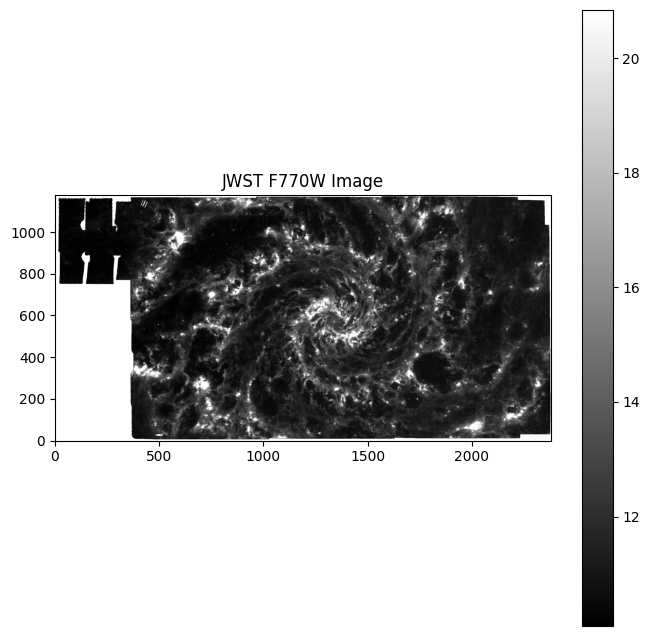

In [522]:
plt.figure(figsize=(8, 8))
plt.imshow(data, origin="lower", cmap="gray",
           vmin=np.nanpercentile(data, 1),
           vmax=np.nanpercentile(data, 99))
plt.colorbar()
plt.title("JWST F770W Image")
plt.show()

In [10]:
plt.imsave(
    "../outputs/figures/ngc628_f770w.png",
    data, 
    cmap="gray",
           vmin=np.nanpercentile(data, 1),
           vmax=np.nanpercentile(data, 99))

In [15]:
data_clean = np.nan_to_num(data, nan=0.0)

In [12]:
p1, p99 = np.percentile(data_clean, (1, 99))
data_clipped = np.clip(data_clean, p1, p99)

data_norm = (data_clipped - p1) / (p99 - p1)

In [14]:
print (data_norm.shape)
print (data_norm.max())

(1177, 2380)
1.0


In [527]:
plt.imsave(
    "../outputs/figures/ngc628_f770w_norm.png",
    data_norm, 
    cmap="gray"
)

In [528]:
# saving ngc 628 png file

# Does directory exist?
os.makedirs("../data/processed/images", exist_ok=True)

# Saving normalized image
np.save("../data/processed/images/ngc628_f770w_norm.npy", data_norm)

In [529]:
# now sanity check

loaded = np.load("../data/processed/images/ngc628_f770w_norm.npy")
print(loaded.shape, loaded.min(), loaded.max())

(1177, 2380) 0.0 1.0


In [530]:
import pandas as pd

df_original = pd.read_csv("../data/raw/catalogue/jwst_bubble_properties_A.txt")

print(df_original.head())
print(df_original.columns)

   ID       RA_DMS      DEC_DMS  SEMI_MAJ_PC  SEMI_MIN_PC  AVG_RAD_PC  PA_DEG  \
0   1  24d08m55.9s   15d48m7.9s           86           86          86       0   
1   2  24d08m56.7s   15d48m2.9s           24           24          24       0   
2   3  24d08m57.0s   15d48m9.0s           42           42          42       0   
3   4  24d08m58.0s  15d47m44.9s           25           25          25       0   
4   5  24d08m58.2s   15d48m2.6s           24           24          24       0   

   ARM  DIST_ARM_PC  GAL_RAD_KPC  
0    3          145         5.22  
1    3          127         5.05  
2    3          138         5.21  
3    3          101         4.54  
4    3          114         4.98  
Index(['ID', 'RA_DMS', 'DEC_DMS', 'SEMI_MAJ_PC', 'SEMI_MIN_PC', 'AVG_RAD_PC',
       'PA_DEG', 'ARM', 'DIST_ARM_PC', 'GAL_RAD_KPC'],
      dtype='str')


In [531]:
print(df_original.columns)

Index(['ID', 'RA_DMS', 'DEC_DMS', 'SEMI_MAJ_PC', 'SEMI_MIN_PC', 'AVG_RAD_PC',
       'PA_DEG', 'ARM', 'DIST_ARM_PC', 'GAL_RAD_KPC'],
      dtype='str')


In [532]:
df_original.head()

,ID,RA_DMS,DEC_DMS,SEMI_MAJ_PC,SEMI_MIN_PC,AVG_RAD_PC,PA_DEG,ARM,DIST_ARM_PC,GAL_RAD_KPC
0,1,24d08m55.9s,15d48m7.9s,86,86,86,0,3,145,5.22
1,2,24d08m56.7s,15d48m2.9s,24,24,24,0,3,127,5.05
2,3,24d08m57.0s,15d48m9.0s,42,42,42,0,3,138,5.21
3,4,24d08m58.0s,15d47m44.9s,25,25,25,0,3,101,4.54
4,5,24d08m58.2s,15d48m2.6s,24,24,24,0,3,114,4.98


In [533]:
cols = ["ID", "RA_DMS", "DEC_DMS", "SEMI_MAJ_PC", "SEMI_MIN_PC", "AVG_RAD_PC", "PA_DEG"]

# look for suspicious area
df_original.loc[1495:1515, cols]

,ID,RA_DMS,DEC_DMS,SEMI_MAJ_PC,SEMI_MIN_PC,AVG_RAD_PC,PA_DEG
1495,1496,24d11m9.2s,15d48m2.9s,18,18,18,0
1496,1497,24d11m9.3s,15d46m39.3s,16,16,16,0
1497,1498,24d11m9.4s,15d47m17.4s,37,37,37,0
1498,1499,24d11m9.4s,15d46m31.0s,15,14,15,0
1499,1500,24d11m9.4s,15d47m6.1s,24,24,24,0
1500,1501,24d11m9.4s,15d46m37.3s,29,29,29,0
1501,1502,24d11m9.4s,15d46m56.4s,53,53,53,0
1502,1503,24d11m9.5s,15d47m15.9s,12,10,11,0
1503,1504,24d11m9.5s,15d47m19.1s,42,42,42,0
1504,1505,24d11m9.6s,15d46m34.5s,69,56,64,50


In [534]:
compare = df_original.copy()
compare[["SEMI_MAJ_PC_shift", "SEMI_MIN_PC_shift", "AVG_RAD_PC_shift"]] = (
    df_original[["SEMI_MAJ_PC", "SEMI_MIN_PC", "AVG_RAD_PC"]].shift(1)
)

compare.loc[1495:1515, [
    "ID", "RA_DMS", "DEC_DMS",
    "SEMI_MAJ_PC", "SEMI_MIN_PC", "AVG_RAD_PC",
    "SEMI_MAJ_PC_shift", "SEMI_MIN_PC_shift", "AVG_RAD_PC_shift",
    "PA_DEG"
]]

,ID,RA_DMS,DEC_DMS,SEMI_MAJ_PC,SEMI_MIN_PC,AVG_RAD_PC,SEMI_MAJ_PC_shift,SEMI_MIN_PC_shift,AVG_RAD_PC_shift,PA_DEG
1495,1496,24d11m9.2s,15d48m2.9s,18,18,18,33.0,33.0,33.0,0
1496,1497,24d11m9.3s,15d46m39.3s,16,16,16,18.0,18.0,18.0,0
1497,1498,24d11m9.4s,15d47m17.4s,37,37,37,16.0,16.0,16.0,0
1498,1499,24d11m9.4s,15d46m31.0s,15,14,15,37.0,37.0,37.0,0
1499,1500,24d11m9.4s,15d47m6.1s,24,24,24,15.0,14.0,15.0,0
1500,1501,24d11m9.4s,15d46m37.3s,29,29,29,24.0,24.0,24.0,0
1501,1502,24d11m9.4s,15d46m56.4s,53,53,53,29.0,29.0,29.0,0
1502,1503,24d11m9.5s,15d47m15.9s,12,10,11,53.0,53.0,53.0,0
1503,1504,24d11m9.5s,15d47m19.1s,42,42,42,12.0,10.0,11.0,0
1504,1505,24d11m9.6s,15d46m34.5s,69,56,64,42.0,42.0,42.0,50


In [535]:
# adjusting for column shift
size_cols = ["SEMI_MAJ_PC", "SEMI_MIN_PC", "AVG_RAD_PC"]

df_shifted = df_original.copy()

size_cols = ["SEMI_MAJ_PC", "SEMI_MIN_PC", "AVG_RAD_PC"]

# move ellipse dimensions/radii down by one row
df_shifted[size_cols] = df_original[size_cols].shift(1)

# remove first row because it now has NaN size values
df_shifted = df_shifted.dropna(subset=size_cols).reset_index(drop=True)

# check the suspicious rows
df_shifted[df_shifted["ID"].isin([1506, 1507])][
    ["ID", "RA_DMS", "DEC_DMS", "SEMI_MAJ_PC", "SEMI_MIN_PC", "AVG_RAD_PC", "PA_DEG"]
]

,ID,RA_DMS,DEC_DMS,SEMI_MAJ_PC,SEMI_MIN_PC,AVG_RAD_PC,PA_DEG
1504,1506,24d11m9.6s,15d47m1.0s,69.0,56.0,64.0,70
1505,1507,24d11m9.6s,15d46m20.7s,582.0,493.0,552.0,-10


In [536]:
df_shifted.head()

,ID,RA_DMS,DEC_DMS,SEMI_MAJ_PC,SEMI_MIN_PC,AVG_RAD_PC,PA_DEG,ARM,DIST_ARM_PC,GAL_RAD_KPC
0,2,24d08m56.7s,15d48m2.9s,86.0,86.0,86.0,0,3,127,5.05
1,3,24d08m57.0s,15d48m9.0s,24.0,24.0,24.0,0,3,138,5.21
2,4,24d08m58.0s,15d47m44.9s,42.0,42.0,42.0,0,3,101,4.54
3,5,24d08m58.2s,15d48m2.6s,25.0,25.0,25.0,0,3,114,4.98
4,6,24d08m58.7s,15d47m41.2s,24.0,24.0,24.0,0,3,95,4.44


In [537]:
if isCatalogueOriginal:
    df=df_original
else: 
    df=df_shifted

In [538]:

wcs = WCS(header)
print(wcs)

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN'
CUNIT : 'deg' 'deg'
CRVAL : 24.171680195437894 15.788156932392056
CRPIX : 1176.2406743555237 589.0158147454987
PC1_1 PC1_2  : 0.3421816464879256 -0.939633822723944
PC2_1 PC2_2  : -0.939633822723944 -0.3421816464879256
CDELT : 3.08127265990853e-05 3.08127265990853e-05
NAXIS : 2380  1177


Set DATE-AVG to '2022-07-17T12:01:53.586' from MJD-AVG.
Set DATE-END to '2022-07-17T12:54:46.016' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -37.754891 from OBSGEO-[XYZ].
Set OBSGEO-H to 1738895745.202 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [539]:

ra_dms = df['RA_DMS'].tolist()      # degree to dms
dec_dms = df['DEC_DMS'].tolist()

def ra_dec_to_deg(ra_str, dec_str):
    ra_pattern = re.compile(r'(\d+)d(\d+)m(\d+\.\d+)s')
    dec_pattern = re.compile(r'(\d+)d(\d+)m(\d+\.\d+)s')
    ra_deg, ra_min, ra_sec = map(float, ra_pattern.match(ra_str).groups())
    dec_deg, dec_min, dec_sec = map(float, dec_pattern.match(dec_str).groups())
    ra_decimal = ra_deg + ra_min / 60 + ra_sec / 3600
    dec_decimal = dec_deg + dec_min / 60 + dec_sec / 3600

    return ra_decimal, dec_decimal

def deg_to_dec(data_in_str):
    data_pattern = re.compile(r'(\d+)d(\d+)m(\d+\.\d+)s')
    data_deg, data_min, data_sec = map(float, data_pattern.match(data_in_str).groups())
    data_in_decimal = data_deg + data_min / 60 + data_sec / 3600

    return data_in_decimal


ra_degrees = np.zeros(len(df), dtype=float)
dec_degrees = np.zeros(len(df), dtype=float)
for i, row in df.iterrows():
    ra_deg, dec_deg = ra_dec_to_deg(row['RA_DMS'], row['DEC_DMS'])
    ra_degrees[i] = ra_deg
    dec_degrees[i] = dec_deg


In [540]:
# x_pix, y_pix = wcs.world_to_pixel_values(ra, dec)
x_pix, y_pix = wcs.all_world2pix(ra_degrees, dec_degrees, 0)


In [541]:
# print(x_pix[1506:1507], y_pix[1506:1507])
# ra_dms=row['RA_DMS']
# dec_dms=row['DEC_DMS']
print(ra_dms[1506:1507], dec_dms[1506:1507])


['24d11m9.6s'] ['15d46m20.7s']


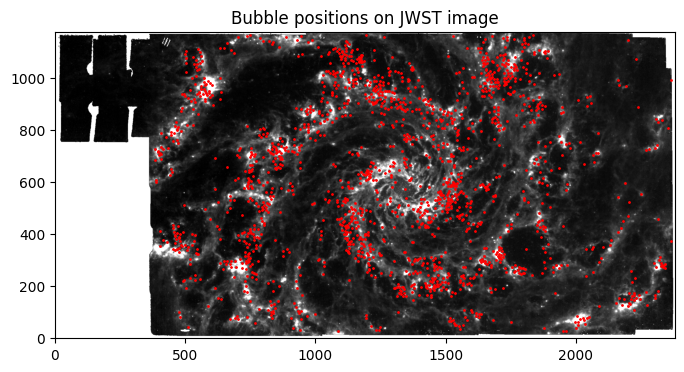

In [542]:
# sanity check  

plt.figure(figsize=(8, 8))
# plt.imshow(data_norm, origin="lower", cmap="gray")
plt.imshow(data, origin="lower", cmap="gray",
           vmin=np.nanpercentile(data, 1),
           vmax=np.nanpercentile(data, 99))

plt.scatter(x_pix, y_pix, s=1, color='red')
plt.title("Bubble positions on JWST image")

plt.show()

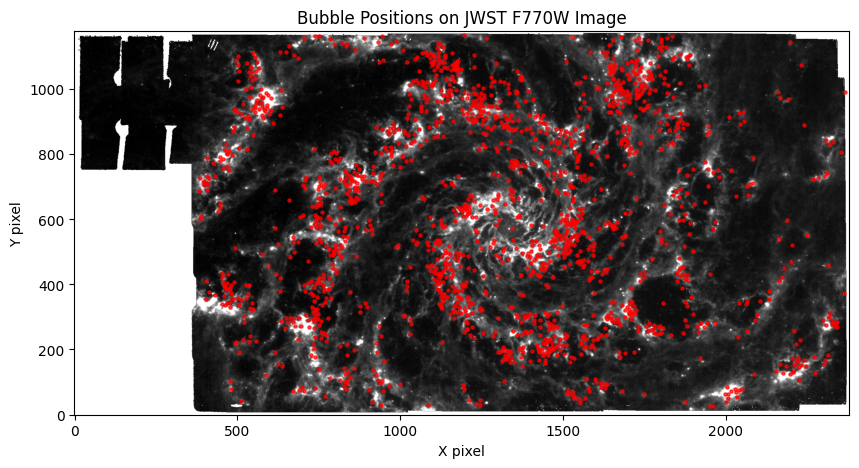

In [543]:
# saving bubble position overlay png file

os.makedirs("../outputs/figures", exist_ok=True)

plt.figure(figsize=(10, 10))
plt.imshow(data, origin="lower", cmap="gray",
           vmin=np.nanpercentile(data, 1),
           vmax=np.nanpercentile(data, 99))
plt.scatter(x_pix, y_pix, s=5, color="red", alpha=0.7)
plt.title("Bubble Positions on JWST F770W Image")
plt.xlabel("X pixel")
plt.ylabel("Y pixel")

plt.savefig(
    "../outputs/figures/ngc628_f770w_bubble_positions_overlay.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [544]:
# mask generation :  parsec to pixel


# Distance to NGC 628 in parsecs
distance_pc = 9.77e6

# Pixel scale from FITS header
pixel_scale_deg = abs(header['CDELT1'])
pixel_scale_arcsec = pixel_scale_deg * 3600

# Physical scale
pc_per_arcsec = distance_pc / 206265
pc_per_pixel = pixel_scale_arcsec * pc_per_arcsec

print("pc per pixel:", pc_per_pixel)

pc per pixel: 5.254140159227344


In [545]:
# semi major and semi minor conversion

semi_major_pix = df['SEMI_MAJ_PC'] / pc_per_pixel
semi_minor_pix = df['SEMI_MIN_PC'] / pc_per_pixel
pa_deg = df['PA_DEG']

In [548]:
height, width = mask.shape

for i in range(len(df)):
    x0 = x_pix[i]
    y0 = y_pix[i]

    a = semi_major_pix.iloc[i]
    b = semi_minor_pix.iloc[i]
    pa = np.deg2rad(pa_deg.iloc[i])

    if np.isnan(x0) or np.isnan(y0) or np.isnan(a) or np.isnan(b):
        continue

    rr, cc = ellipse(
        r=y0,
        c=x0,
        r_radius=b,
        c_radius=a,
        rotation=pa,
        shape=mask.shape
    )

    mask[rr, cc] = 1

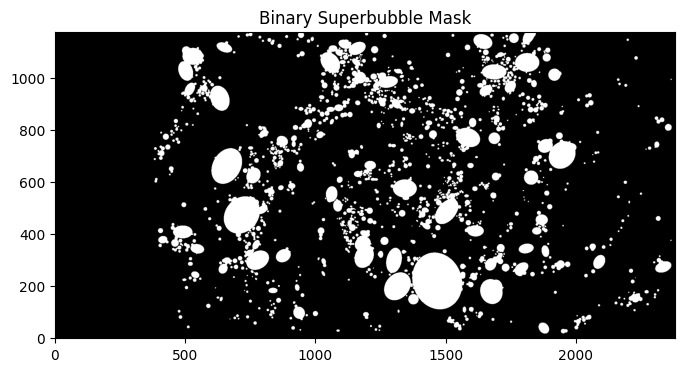

In [549]:
plt.figure(figsize=(8, 8))
plt.imshow(mask, origin="lower", cmap="gray")
plt.title("Binary Superbubble Mask")
plt.show()

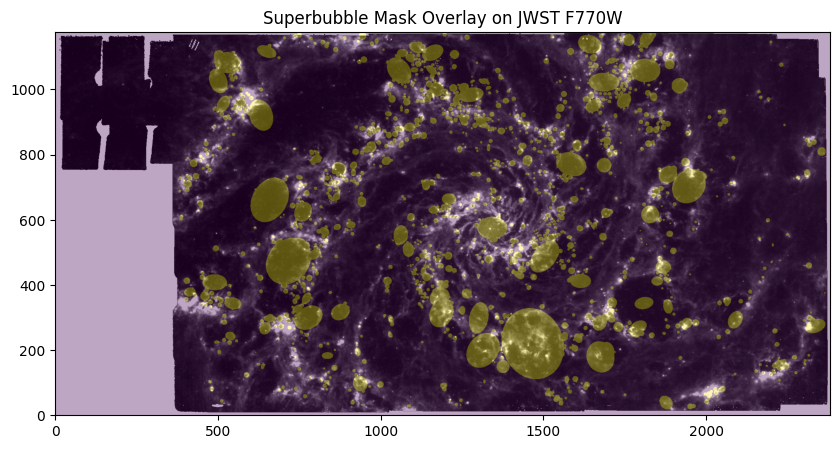

In [550]:
plt.figure(figsize=(10, 10))
plt.imshow(data, origin="lower", cmap="gray",
           vmin=np.nanpercentile(data, 1),
           vmax=np.nanpercentile(data, 99))
plt.imshow(mask, origin="lower", alpha=0.35)
plt.title("Superbubble Mask Overlay on JWST F770W")
plt.show()

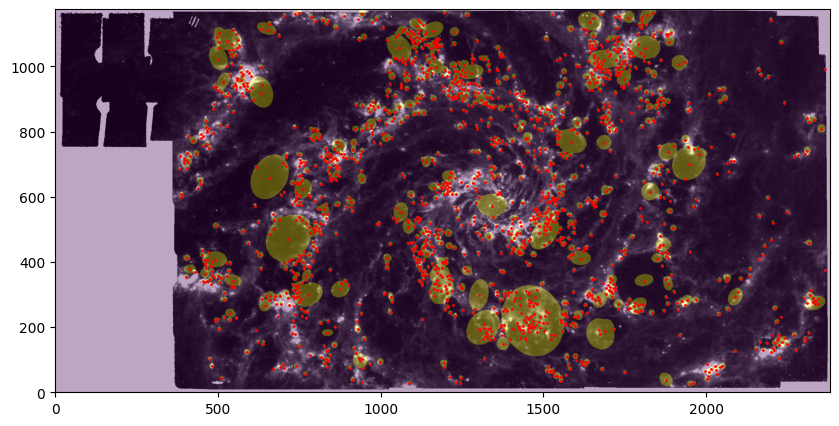

In [551]:
plt.figure(figsize=(10, 10))
plt.imshow(data, origin="lower", cmap="gray",
           vmin=np.nanpercentile(data, 1),
           vmax=np.nanpercentile(data, 99))
plt.imshow(mask, origin="lower", alpha=0.35)

plt.scatter(x_pix, y_pix, s=1, color='red')


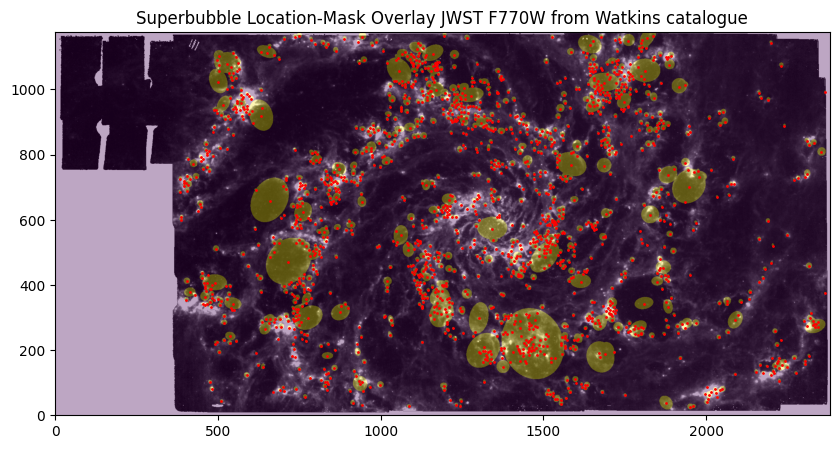

In [552]:
# saving mask and location overlay png file

plt.figure(figsize=(10, 10))
plt.imshow(data, origin="lower", cmap="gray",
           vmin=np.nanpercentile(data, 1),
           vmax=np.nanpercentile(data, 99))
plt.imshow(mask, origin="lower", alpha=0.35)
plt.scatter(x_pix, y_pix, s=1, color='red')


if isCatalogueOriginal:
    plt.title("Superbubble Location-Mask Overlay JWST F770W from Watkins catalogue")
    plt.savefig(
        "../outputs/figures/ngc628_superbubble_location-mask_overlay.png",
        dpi=300,
        bbox_inches="tight"
    )
else: 
    plt.title("Superbubble Location-Mask Overlay JWST F770W from adjusted catalogue")
    plt.savefig(
        "../outputs/figures/ngc628_superbubble_location-mask_overlay_adjusted.png",
        dpi=300,
        bbox_inches="tight"
    )
plt.show()

In [553]:
os.makedirs("../data/processed/masks", exist_ok=True)

np.save("../data/processed/masks/ngc628_superbubble_mask.npy", mask)

In [554]:
loaded = np.load("../data/processed/masks/ngc628_superbubble_mask.npy")
print(loaded.shape, loaded.min(), loaded.max())

(1177, 2380) 0 1


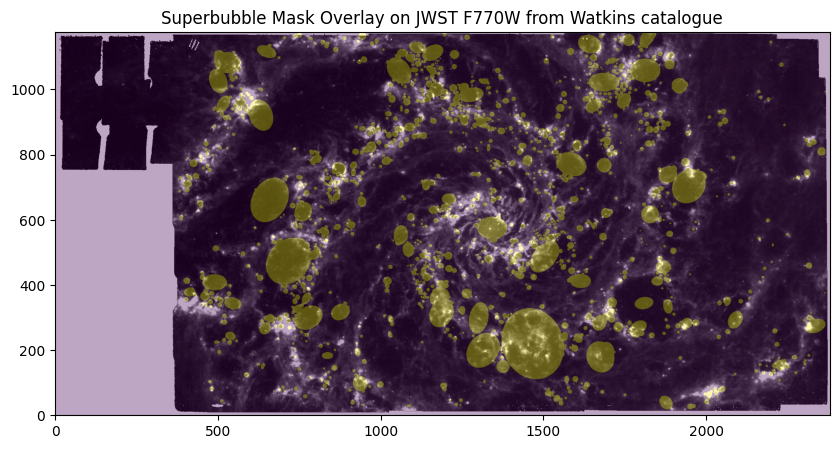

In [555]:
# saving mask overlay png file

plt.figure(figsize=(10, 10))
plt.imshow(data, origin="lower", cmap="gray",
           vmin=np.nanpercentile(data, 1),
           vmax=np.nanpercentile(data, 99))
plt.imshow(mask, origin="lower", alpha=0.35)

if isCatalogueOriginal:
    
    plt.title("Superbubble Mask Overlay on JWST F770W from Watkins catalogue")
    plt.savefig(
        "../outputs/figures/ngc628_superbubble_mask_overlay.png",
        dpi=300,
        bbox_inches="tight"
    )

else:
    plt.title("Superbubble Mask Overlay on JWST F770W from adjusted catalogue")
    plt.savefig(
        "../outputs/figures/ngc628_superbubble_mask_overlay_adjusted.png",
        dpi=300,
        bbox_inches="tight"
    )
plt.show()

ID 1505: pixel=(1691.36, 300.01), a=13.23, b=10.74, theta=40.00
ID 1506: pixel=(1466.88, 218.28), a=111.63, b=94.56, theta=20.00
ID 1507: pixel=(1808.26, 342.57), a=29.35, b=18.61, theta=100.00


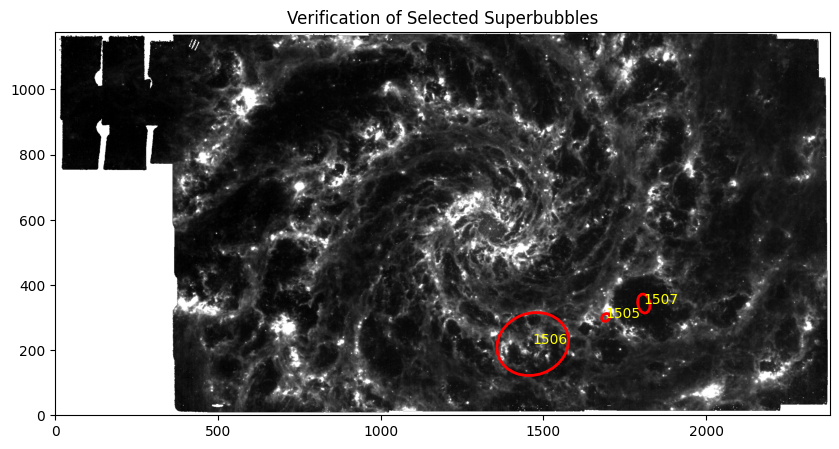

In [566]:
# -----------------------------
# Bubble entries
# -----------------------------
bubbles = [
    {"id":1505, "ra":"24d11m9.6s", "dec":"15d46m34.5s", "a":69,  "b":56,  "pa":50},
    {"id":1506, "ra":"24d11m9.6s", "dec":"15d47m1.0s",  "a":582, "b":493, "pa":70},
    {"id":1507, "ra":"24d11m9.6s", "dec":"15d46m20.7s", "a":153, "b":97,  "pa":-10},
]

fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(data, cmap='gray', origin='lower',
           vmin=np.nanpercentile(data, 1),
           vmax=np.nanpercentile(data, 99))

for bubble in bubbles:
    coord = SkyCoord(bubble["ra"], bubble["dec"], frame="icrs")
    
    x, y = wcs.world_to_pixel(coord)

    # pc to pixels
    a_pix = bubble["a"] / pc_per_pixel
    b_pix = bubble["b"] / pc_per_pixel

    # PA to matplotlib convention
    theta = -(bubble["pa"] - 90)

    # Drawing ellipse
    e = Ellipse(
        (x, y),
        width=2*a_pix,
        height=2*b_pix,
        angle=theta,
        edgecolor='red',
        facecolor='none',
        linewidth=2
    )
    ax.add_patch(e)

    # Label ID
    ax.text(x, y, str(bubble["id"]), color='yellow', fontsize=10)

    print(f"ID {bubble['id']}: pixel=({x:.2f}, {y:.2f}), a={a_pix:.2f}, b={b_pix:.2f}, theta={theta:.2f}")

plt.title("Verification of Selected Superbubbles")
plt.show()
